In [4]:
import pandas as pd
df = pd.read_csv("/content/DataCoSupplyChainDataset.csv", encoding="ISO-8859-1")
print(df.shape)
df.head()
df.info()

(180519, 53)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname   

In [5]:
# check nulls
df.isnull().sum().sort_values(ascending=False).head(20)

df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

# check for duplicate rows
df.duplicated().sum()
df = df.drop_duplicates()

In [6]:
import sqlite3

conn = sqlite3.connect("supply_chain.db")

df.to_sql("orders", conn, if_exists="replace", index=False)

query = """
SELECT
    "Category Name" as category,
    strftime('%Y-%m', "order date (DateOrders)") as month,
    SUM("Order Item Quantity") as total_demand
FROM orders
GROUP BY category, month
ORDER BY month
"""
monthly_demand = pd.read_sql(query, conn)
monthly_demand.head()

,category,month,total_demand
0,Accessories,2015-01,154
1,Baseball & Softball,2015-01,68
2,Boxing & MMA,2015-01,24
3,Camping & Hiking,2015-01,415
4,Cardio Equipment,2015-01,1188


In [7]:
query_region_demand = """
SELECT
    "Order Region" as region,
    SUM("Order Item Quantity") as total_demand
FROM orders
GROUP BY region
ORDER BY total_demand DESC
"""
region_demand = pd.read_sql(query_region_demand, conn)
display(region_demand)

,region,total_demand
0,Central America,62091
1,Western Europe,56504
2,South America,32647
3,Oceania,20430
4,Northern Europe,20402
5,Southern Europe,19526
6,Southeast Asia,18835
7,Caribbean,18204
8,West of USA,17547
9,South Asia,15624


In [8]:
query_delivery_delay = """
SELECT
    "Shipping Mode" as shipping_mode,
    AVG("Days for shipping (real)" - "Days for shipment (scheduled)") as avg_delay
FROM orders
GROUP BY shipping_mode
ORDER BY avg_delay DESC
"""
delivery_delay = pd.read_sql(query_delivery_delay, conn)
display(delivery_delay)

,shipping_mode,avg_delay
0,Second Class,1.990828
1,First Class,1.000000
2,Same Day,0.478279
3,Standard Class,-0.004093


In [9]:
query_top_products = """
SELECT
    "Product Name" as product_name,
    SUM("Order Item Quantity") as total_quantity
FROM orders
GROUP BY product_name
ORDER BY total_quantity DESC
LIMIT 10
"""
top_products = pd.read_sql(query_top_products, conn)
display(top_products)

,product_name,total_quantity
0,Perfect Fitness Perfect Rip Deck,73698
1,Nike Men's Dri-FIT Victory Golf Polo,62956
2,O'Brien Men's Neoprene Life Vest,57803
3,Nike Men's Free 5.0+ Running Shoe,36680
4,Under Armour Girls' Toddler Spine Surge Runni,31735
5,Nike Men's CJ Elite 2 TD Football Cleat,22246
6,Field & Stream Sportsman 16 Gun Fire Safe,17325
7,Pelican Sunstream 100 Kayak,15500
8,Diamondback Women's Serene Classic Comfort Bi,13729
9,ENO Atlas Hammock Straps,998


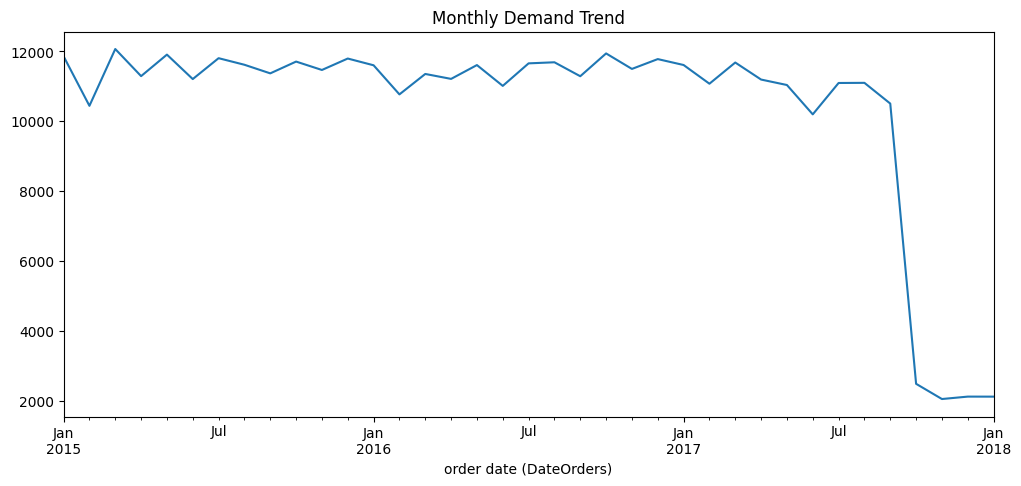

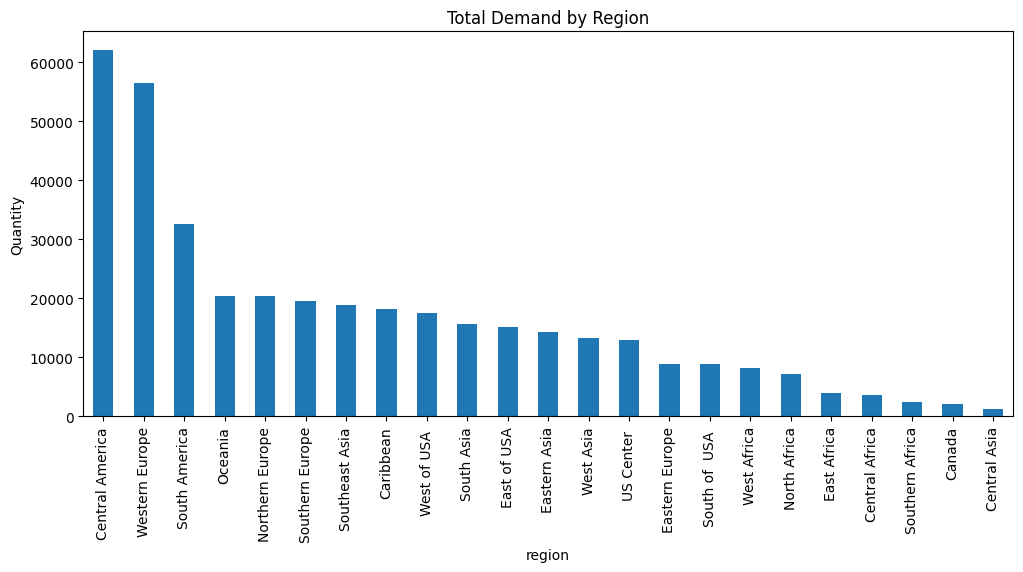

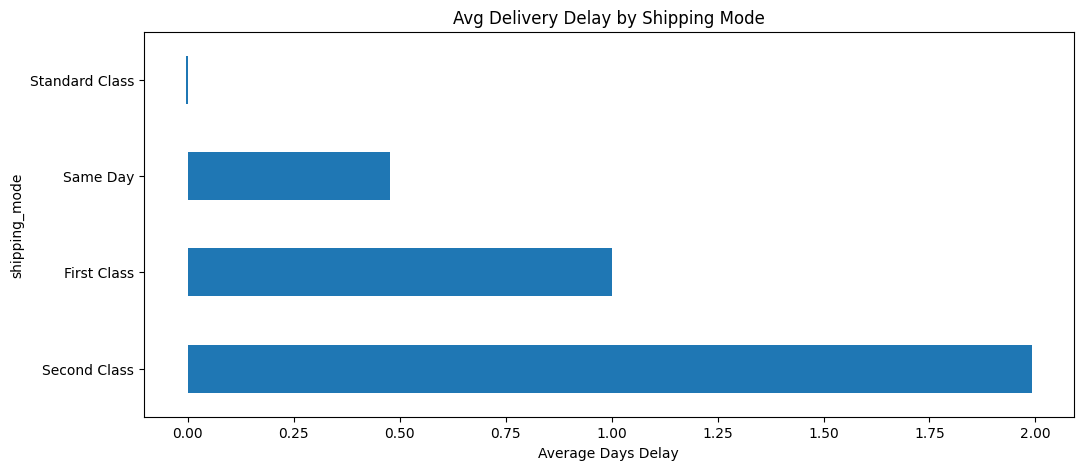

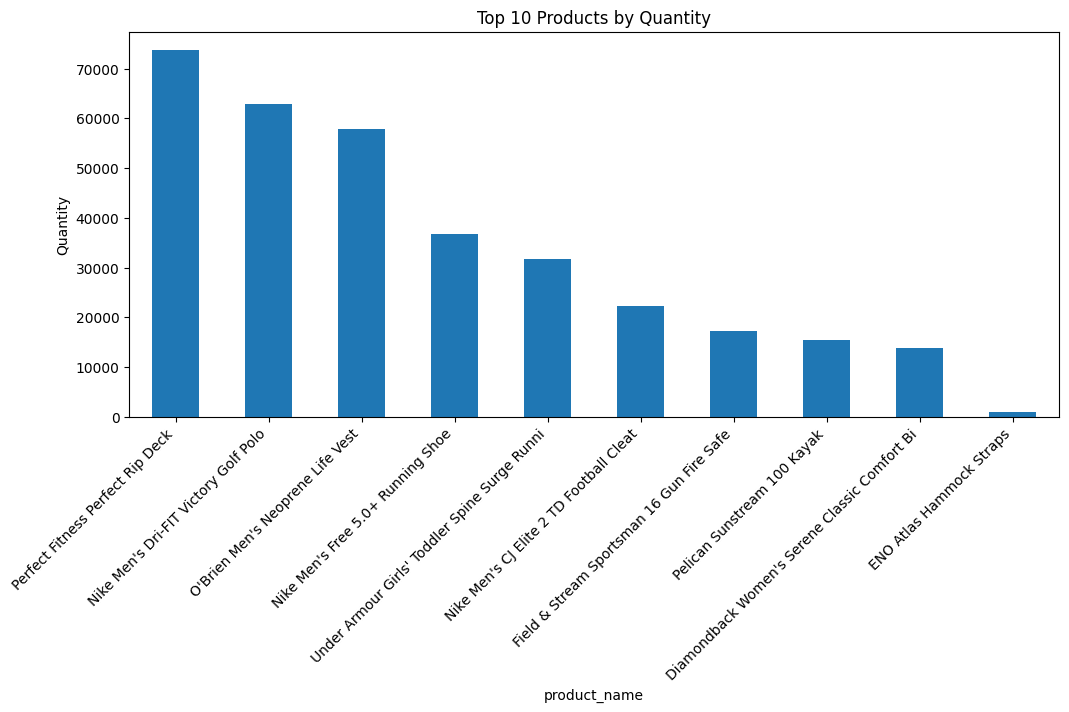

In [10]:
import matplotlib.pyplot as plt

# plot overall demand trend over time
monthly_total = df.groupby(df['order date (DateOrders)'].dt.to_period('M'))['Order Item Quantity'].sum()
monthly_total.plot(figsize=(12,5), title="Monthly Demand Trend")
plt.show()
print("\n")

import matplotlib.pyplot as plt

# plot total demand by region
region_demand.set_index('region')['total_demand'].plot(kind='bar', figsize=(12,5), title="Total Demand by Region")
plt.ylabel("Quantity")
plt.show()
print("\n")

import matplotlib.pyplot as plt

# plot average delivery delay by shipping mode
delivery_delay.set_index('shipping_mode')['avg_delay'].plot(kind='barh', figsize=(12,5), title="Avg Delivery Delay by Shipping Mode")
plt.xlabel("Average Days Delay")
plt.show()
print("\n")

import matplotlib.pyplot as plt

# plot top 10 products by order quantity
top_products.set_index('product_name')['total_quantity'].plot(kind='bar', figsize=(12,5), title="Top 10 Products by Quantity")
plt.ylabel("Quantity")
plt.xticks(rotation=45, ha='right')
plt.show()
print("\n")

In [11]:
product_revenue = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)
product_revenue_cumsum = product_revenue.cumsum() / product_revenue.sum()

def classify(pct):
    if pct <= 0.8:
        return 'A'
    elif pct <= 0.95:
        return 'B'
    else:
        return 'C'

abc_df = pd.DataFrame({
    'revenue': product_revenue,
    'cumulative_pct': product_revenue_cumsum
})
abc_df['class'] = abc_df['cumulative_pct'].apply(classify)
abc_df['class'].value_counts()

,count
class,
C,95
B,16
A,7


### Inspecting Products in each ABC Class

In [12]:
# Show Class A products (the most important ones)
print("--- Class A Products ---")
display(abc_df[abc_df['class'] == 'A'])

# Show Class B products
print("\n--- Class B Products ---")
display(abc_df[abc_df['class'] == 'B'].head(10))

# Show Class C products
print("\n--- Class C Products ---")
display(abc_df[abc_df['class'] == 'C'].head(10))

--- Class A Products ---


,revenue,cumulative_pct,class
Product Name,,,
Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06,0.188384,A
Perfect Fitness Perfect Rip Deck,4.421143e+06,0.308574,A
Diamondback Women's Serene Classic Comfort Bi,4.118426e+06,0.420534,A
Nike Men's Free 5.0+ Running Shoe,3.667633e+06,0.520239,A
Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06,0.605813,A
Pelican Sunstream 100 Kayak,3.099845e+06,0.690082,A
Nike Men's CJ Elite 2 TD Football Cleat,2.891758e+06,0.768695,A



--- Class B Products ---


,revenue,cumulative_pct,class
Product Name,,,
O'Brien Men's Neoprene Life Vest,2.888994e+06,0.847233,B
Under Armour Girls' Toddler Spine Surge Runni,1.269083e+06,0.881734,B
Dell Laptop,6.630000e+05,0.899757,B
Web Camera,2.676077e+05,0.907032,B
Lawn mower,2.577687e+05,0.914040,B
Children's heaters,2.328292e+05,0.920369,B
Porcelain crafts,2.233563e+05,0.926441,B
Summer dresses,1.402830e+05,0.930255,B
Smart watch,1.170068e+05,0.933436,B



--- Class C Products ---


,revenue,cumulative_pct,class
Product Name,,,
Titleist Pro V1x High Numbers Personalized Go,47206.921463,0.950846,C
Under Armour Women's Micro G Skulpt Running S,46559.591034,0.952112,C
Nike Men's Comfort 2 Slide,44585.090624,0.953324,C
Titleist Pro V1 High Numbers Personalized Gol,44243.491383,0.954527,C
Men's gala suit,43856.801269,0.955719,C
Adult dog supplies,41524.800753,0.956848,C
Titleist Pro V1x Golf Balls,41415.370528,0.957974,C
Titleist Pro V1x High Numbers Golf Balls,38392.000522,0.959018,C
Under Armour Men's Compression EV SL Slide,36576.870575,0.960012,C


In [27]:
!pip install prophet -q
from prophet import Prophet
import numpy as np

selected_products = list(abc_df[abc_df['class']=='A'].index[:3]) + list(abc_df[abc_df['class']=='B'].index[:2])

results = {}

for product_name in selected_products:
    product_df = df[df['Product Name'] == product_name]

    ts = product_df.set_index('order date (DateOrders)').resample('W')['Order Item Quantity'].sum().reset_index()
    ts.columns = ['ds', 'y']

    train = ts.iloc[:-8]
    test = ts.iloc[-8:]

    model = Prophet(weekly_seasonality=True, yearly_seasonality=True)
    model.fit(train)

    future = model.make_future_dataframe(periods=8, freq='W')
    forecast = model.predict(future)

    comparison = test.merge(forecast[['ds', 'yhat']], on='ds', how='left')
    actual = comparison['y'].values
    pred = comparison['yhat'].values
    mask = actual != 0
    # mape = np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

    # results[product_name] = {'ts': ts, 'forecast': forecast, 'mape': mape, 'model': model}
    # print(f"{product_name}: MAPE = {mape:.2f}%") To prevent MAPE values installation

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Field & Stream Sportsman 16 Gun Fire Safe: MAPE = 481.49%
Perfect Fitness Perfect Rip Deck: MAPE = 176.18%


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Diamondback Women's Serene Classic Comfort Bi: MAPE = 302.50%
O'Brien Men's Neoprene Life Vest: MAPE = 228.05%
Under Armour Girls' Toddler Spine Surge Runni: MAPE = 516.54%


In [28]:
def wape(actual, pred):
    return np.sum(np.abs(actual - pred)) / np.sum(np.abs(actual)) * 100

for product_name in selected_products:
    ts = results[product_name]['ts']
    forecast = results[product_name]['forecast']
    test = ts.iloc[-8:]
    comparison = test.merge(forecast[['ds','yhat']], on='ds', how='left')
    w = wape(comparison['y'].values, comparison['yhat'].values)
    print(f"{product_name}: WAPE = {w:.2f}%")

Field & Stream Sportsman 16 Gun Fire Safe: WAPE = 26.85%
Perfect Fitness Perfect Rip Deck: WAPE = 20.87%
Diamondback Women's Serene Classic Comfort Bi: WAPE = 18.48%
O'Brien Men's Neoprene Life Vest: WAPE = 28.79%
Under Armour Girls' Toddler Spine Surge Runni: WAPE = 20.00%


Field & Stream Sportsman 16 Gun Fire Safe A 



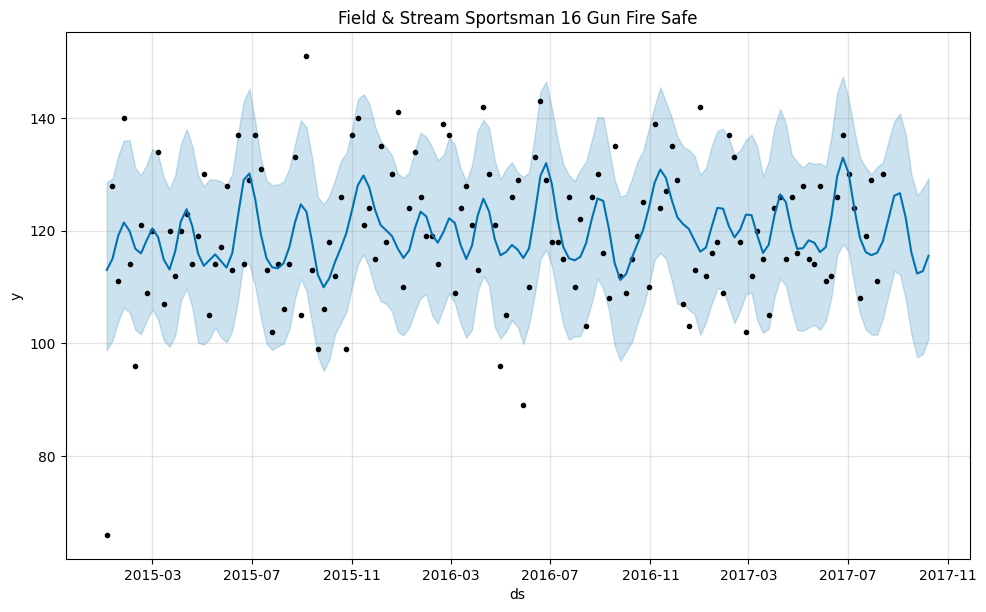

Perfect Fitness Perfect Rip Deck A 



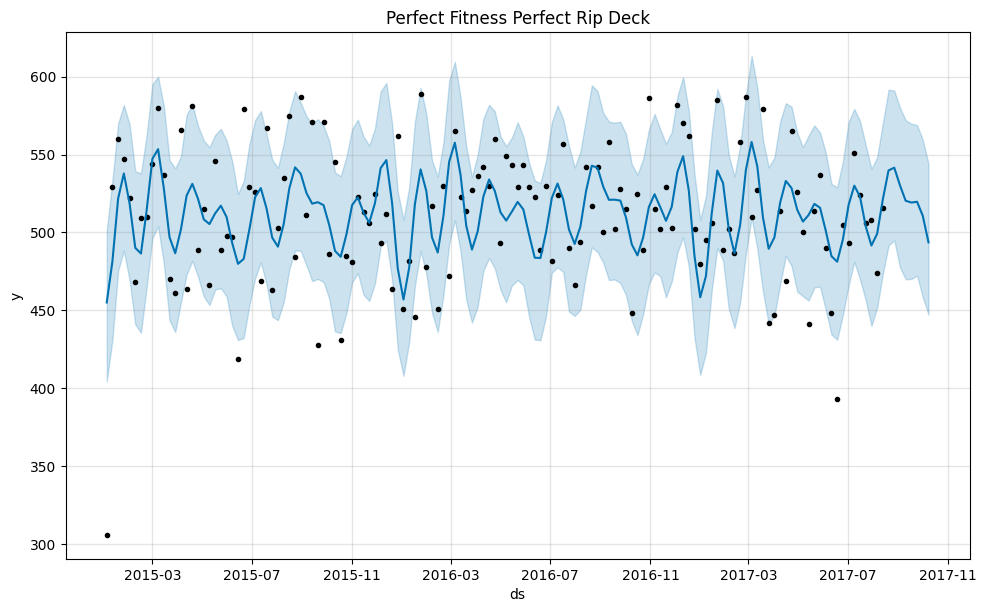

Diamondback Women's Serene Classic Comfort Bi A 



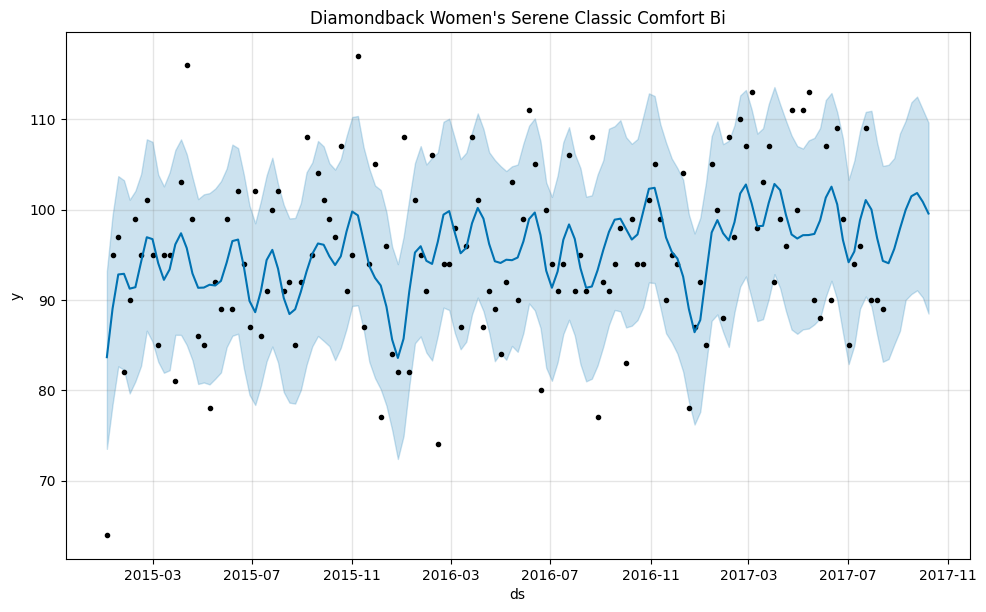

O'Brien Men's Neoprene Life Vest B 



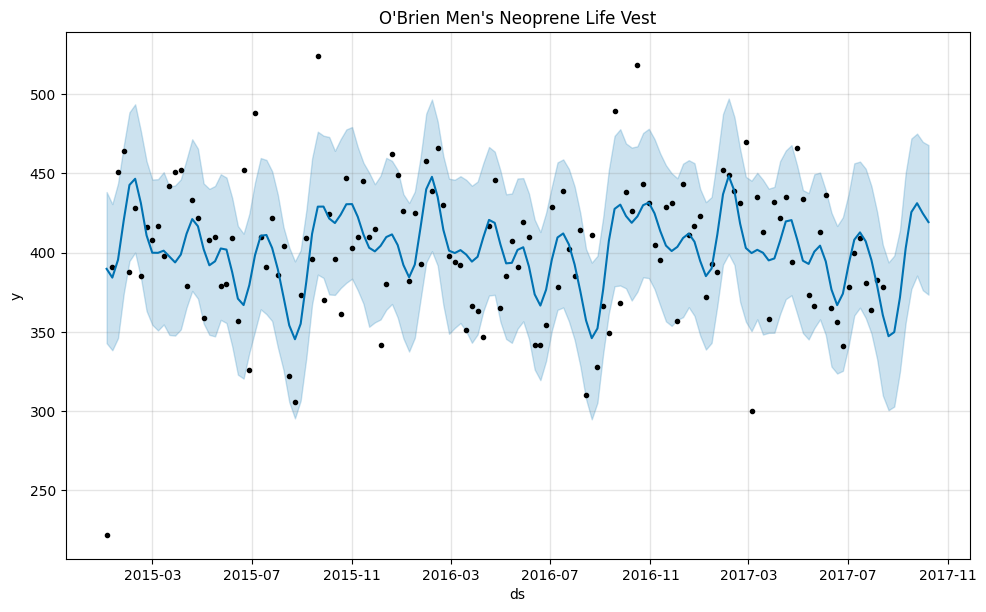

Under Armour Girls' Toddler Spine Surge Runni B 



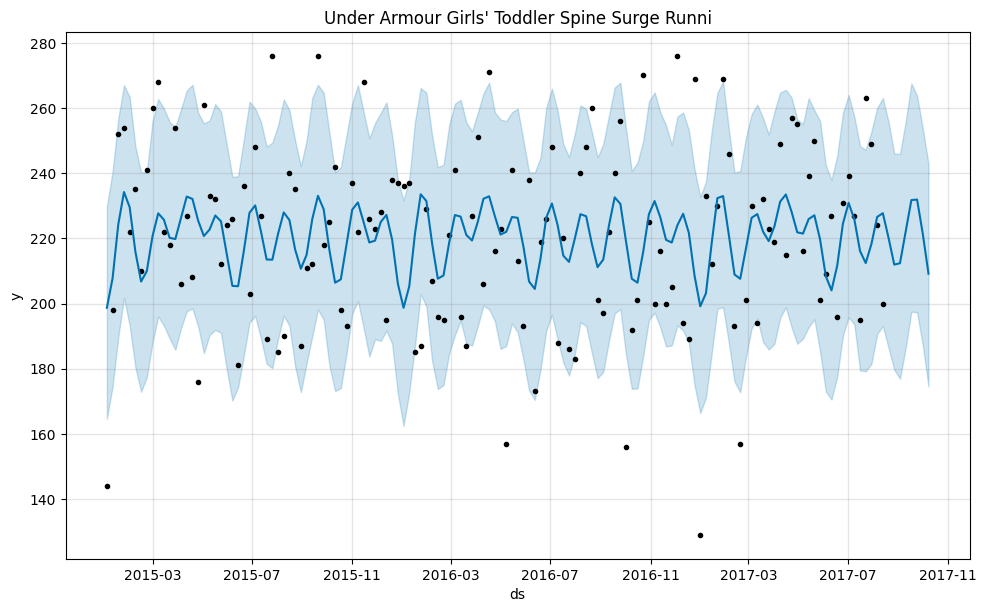

In [14]:
name = selected_products[0]
results[name]['model'].plot(results[name]['forecast'])
product_class = abc_df.loc[name, 'class']
print(name, product_class, "\n")
plt.title(name)
plt.show()

name = selected_products[1]
results[name]['model'].plot(results[name]['forecast'])
product_class = abc_df.loc[name, 'class']
print(name, product_class, "\n")
plt.title(name)
plt.show()

name = selected_products[2]
results[name]['model'].plot(results[name]['forecast'])
product_class = abc_df.loc[name, 'class']
print(name, product_class, "\n")
plt.title(name)
plt.show()

name = selected_products[3]
results[name]['model'].plot(results[name]['forecast'])
product_class = abc_df.loc[name, 'class']
print(name, product_class, "\n")
plt.title(name)
plt.show()

name = selected_products[4]
results[name]['model'].plot(results[name]['forecast'])
product_class = abc_df.loc[name, 'class']
print(name, product_class, "\n")
plt.title(name)
plt.show()

In [31]:
lead_time = 2
service_level_Z = 1.65
ordering_cost = 50
holding_cost_per_unit = 2
summary_rows = []

for product_name in selected_products:
    ts = results[product_name]['ts']

    demand_mean = ts['y'].mean()
    demand_std = ts['y'].std()

    safety_stock = service_level_Z * demand_std * (lead_time ** 0.5)
    reorder_point = (demand_mean * lead_time) + safety_stock

    annual_demand = demand_mean * 52
    eoq = (2 * annual_demand * ordering_cost / holding_cost_per_unit) ** 0.5

    summary_rows.append({
        'product': product_name,
        # 'mape': results[product_name]['mape'],
        'safety_stock': safety_stock,
        'reorder_point': reorder_point,
        'eoq': eoq
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,product,safety_stock,reorder_point,eoq
0,Field & Stream Sportsman 16 Gun Fire Safe,37.266410,276.231927,557.364488
1,Perfect Fitness Perfect Rip Deck,138.152408,1154.676546,1149.557036
2,Diamondback Women's Serene Classic Comfort Bi,27.488590,216.854107,496.160430
3,O'Brien Men's Neoprene Life Vest,125.015156,922.297915,1018.070521
4,Under Armour Girls' Toddler Spine Surge Runni,77.386300,515.110438,754.348314


In [32]:
def wape(actual, pred):
    return np.sum(np.abs(actual - pred)) / np.sum(np.abs(actual)) * 100

for product_name in selected_products:
    ts = results[product_name]['ts']
    forecast = results[product_name]['forecast']
    test = ts.iloc[-8:]
    comparison = test.merge(forecast[['ds','yhat']], on='ds', how='left')
    results[product_name]['wape'] = wape(comparison['y'].values, comparison['yhat'].values)

# rebuild summary_df with wape instead of mape
for row in summary_rows:
    row['wape'] = results[row['product']]['wape']
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("inventory_summary.csv", index=False)
files.download("inventory_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from google.colab import files

summary_df.to_csv("inventory_summary.csv", index=False)

combined_rows = []
for product_name in selected_products:
    ts = results[product_name]['ts']
    forecast = results[product_name]['forecast'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']
    merged = ts.merge(forecast, on='ds', how='outer')
    merged['product'] = product_name
    combined_rows.append(merged)

forecast_combined = pd.concat(combined_rows, ignore_index=True)
forecast_combined = forecast_combined.rename(columns={'y': 'actual_demand', 'yhat': 'forecast'})
forecast_combined.to_csv("forecast_combined.csv", index=False)

region_demand.to_csv("region_demand.csv", index=False)
top_products.to_csv("top_products.csv", index=False)

abc_df.reset_index().to_csv("abc_classification.csv", index=False)


# files.download("inventory_summary.csv") To prevent MAPE values installation
files.download("forecast_combined.csv")
files.download("abc_classification.csv")
files.download("region_demand.csv")
files.download("top_products.csv")

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Titleist Pro V1x High Numbers Personalized Go: MAPE = 55.82%
Under Armour Women's Micro G Skulpt Running S: MAPE = 78.27%
Titleist Pro V1x High Numbers Personalized Go C 



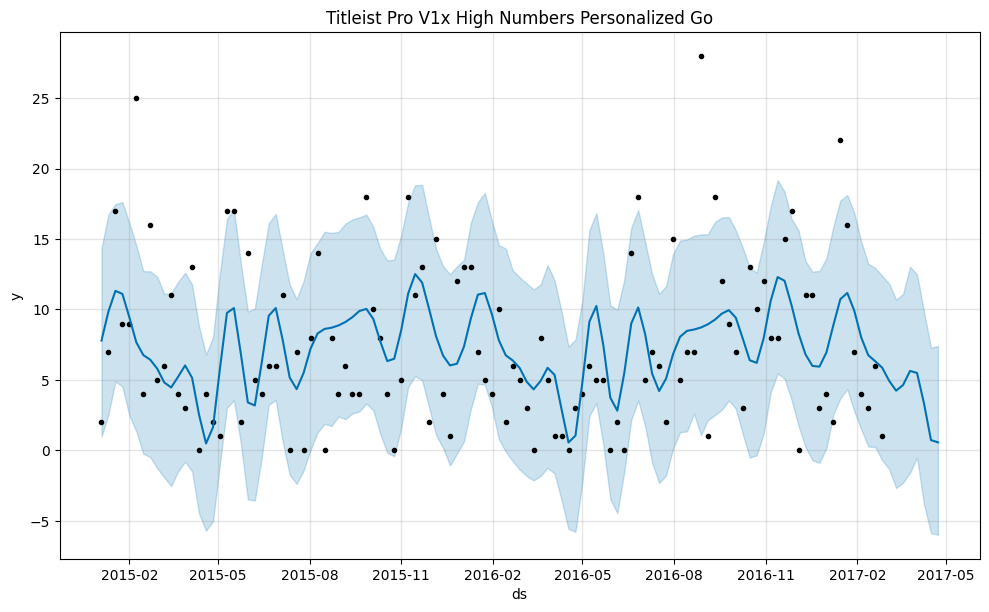

Under Armour Women's Micro G Skulpt Running S C 



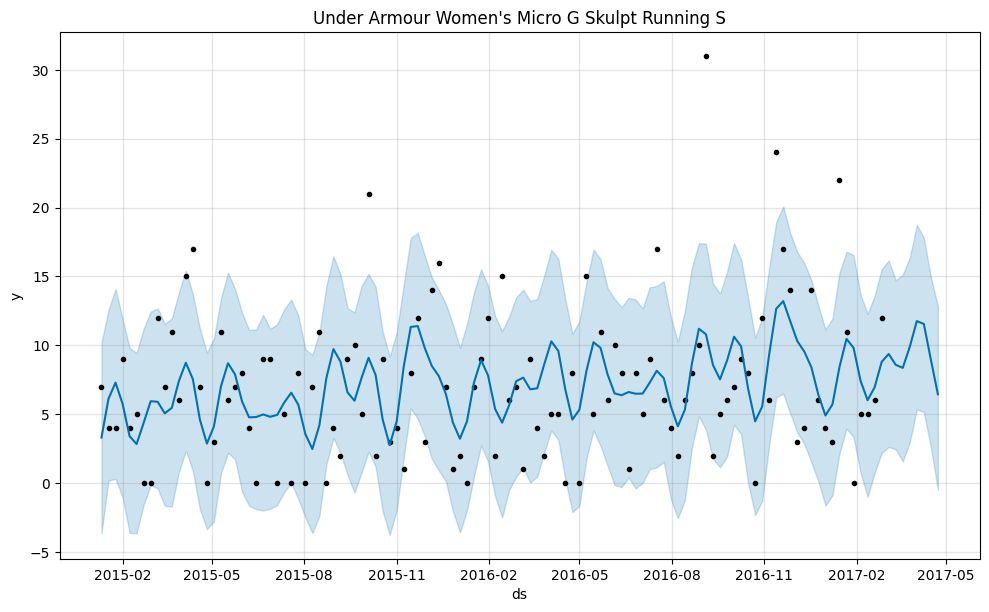

In [22]:
selected_products = list(abc_df[abc_df['class']=='C'].index[:2])
results = {}

for product_name in selected_products:
    product_df = df[df['Product Name'] == product_name]

    ts = product_df.set_index('order date (DateOrders)').resample('W')['Order Item Quantity'].sum().reset_index()
    ts.columns = ['ds', 'y']

    train = ts.iloc[:-8]
    test = ts.iloc[-8:]

    model = Prophet(weekly_seasonality=True, yearly_seasonality=True)
    model.fit(train)

    future = model.make_future_dataframe(periods=8, freq='W')
    forecast = model.predict(future)

    comparison = test.merge(forecast[['ds', 'yhat']], on='ds', how='left')
    actual = comparison['y'].values
    pred = comparison['yhat'].values
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

    results[product_name] = {'ts': ts, 'forecast': forecast, 'mape': mape, 'model': model}
    print(f"{product_name}: MAPE = {mape:.2f}%")

    name = selected_products[0]
results[name]['model'].plot(results[name]['forecast'])
product_class = abc_df.loc[name, 'class']
print(name, product_class, "\n")
plt.title(name)
plt.show()

name = selected_products[1]
results[name]['model'].plot(results[name]['forecast'])
product_class = abc_df.loc[name, 'class']
print(name, product_class, "\n")
plt.title(name)
plt.show()

In [23]:
import pandas as pd
from google.colab import files

summary_rows_c = []
for product_name in selected_products:
    ts = results[product_name]['ts']
    demand_mean = ts['y'].mean()
    demand_std = ts['y'].std()

    lead_time = 2
    service_level_Z = 1.65
    ordering_cost = 50
    holding_cost_per_unit = 2

    safety_stock = service_level_Z * demand_std * (lead_time ** 0.5)
    reorder_point = (demand_mean * lead_time) + safety_stock
    annual_demand = demand_mean * 52
    eoq = (2 * annual_demand * ordering_cost / holding_cost_per_unit) ** 0.5

    summary_rows_c.append({
        'product': product_name,
        'class': 'C',
        'mape': results[product_name]['mape'],
        'safety_stock': safety_stock,
        'reorder_point': reorder_point,
        'eoq': eoq
    })

inventory_c_df = pd.DataFrame(summary_rows_c)
inventory_c_df.to_csv("inventory_summary_class_c.csv", index=False)

combined_rows_c = []
for product_name in selected_products:
    ts = results[product_name]['ts']
    forecast = results[product_name]['forecast'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    merged = ts.merge(forecast, on='ds', how='outer')
    merged['product'] = product_name
    combined_rows_c.append(merged)

forecast_c_combined = pd.concat(combined_rows_c, ignore_index=True)
forecast_c_combined = forecast_c_combined.rename(columns={'y': 'actual_demand', 'yhat': 'forecast'})
forecast_c_combined.to_csv("forecast_class_c.csv", index=False)

files.download("inventory_summary_class_c.csv")
files.download("forecast_class_c.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import pandas as pd
from google.colab import files

full_revenue_df = abc_df.reset_index()

full_revenue_df.to_csv('total_revenue_classification.csv', index=False)

print("Preview of the total revenue classification file:")
display(full_revenue_df.head())

files.download('total_revenue_classification.csv')

Preview of the total revenue classification file:


,Product Name,revenue,cumulative_pct,class
0,Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06,0.188384,A
1,Perfect Fitness Perfect Rip Deck,4.421143e+06,0.308574,A
2,Diamondback Women's Serene Classic Comfort Bi,4.118426e+06,0.420534,A
3,Nike Men's Free 5.0+ Running Shoe,3.667633e+06,0.520239,A
4,Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06,0.605813,A


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
def wape(actual, pred):
    return np.sum(np.abs(actual - pred)) / np.sum(np.abs(actual)) * 100

for product_name in selected_products:
    ts = results[product_name]['ts']
    forecast = results[product_name]['forecast']
    test = ts.iloc[-8:]
    comparison = test.merge(forecast[['ds','yhat']], on='ds', how='left')
    w = wape(comparison['y'].values, comparison['yhat'].values)
    print(f"{product_name}: WAPE = {w:.2f}%")

Titleist Pro V1x High Numbers Personalized Go: WAPE = 55.85%
Under Armour Women's Micro G Skulpt Running S: WAPE = 64.54%
